In [1]:
!pip install torch matplotlib

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

Epoch 1/20, Loss: 1.2634
Epoch 2/20, Loss: 1.0424
Epoch 3/20, Loss: 1.0369
Epoch 4/20, Loss: 1.0319
Epoch 5/20, Loss: 1.0265
Epoch 6/20, Loss: 1.0248
Epoch 7/20, Loss: 1.0212
Epoch 8/20, Loss: 1.0174
Epoch 9/20, Loss: 1.0135
Epoch 10/20, Loss: 1.0129
Epoch 11/20, Loss: 1.0104
Epoch 12/20, Loss: 1.0077
Epoch 13/20, Loss: 1.0050
Epoch 14/20, Loss: 1.0042
Epoch 15/20, Loss: 1.0028
Epoch 16/20, Loss: 1.0032
Epoch 17/20, Loss: 1.0028
Epoch 18/20, Loss: 1.0027
Epoch 19/20, Loss: 1.0022
Epoch 20/20, Loss: 1.0014


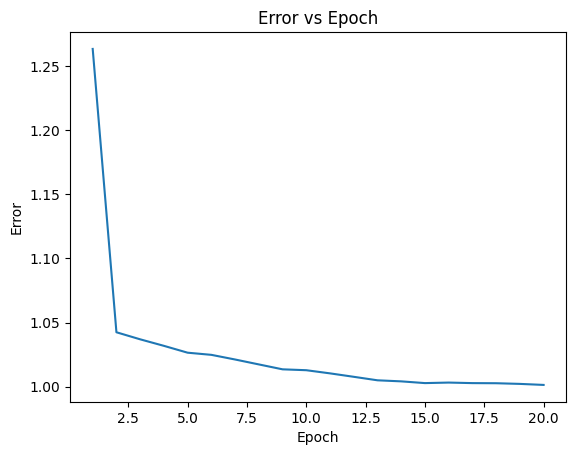

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset
def generate_synthetic_data(num_samples, seq_len, input_dim, output_dim):
    X = torch.randn(num_samples, seq_len, input_dim)
    Y = torch.randn(num_samples, seq_len, output_dim)
    return X, Y

# MultiheadedAttention block
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert (
            self.head_dim * heads == embed_size
        ), "Embedding size needs to be divisible by heads"

        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)

        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)

        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_size ** (1/2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out

# Transformer block
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.ReLU(),
            nn.Linear(forward_expansion * embed_size, embed_size)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward + x))
        return out

# Transformer
class Transformer(nn.Module):
    def __init__(self, embed_size, num_layers, heads, device, forward_expansion, dropout, input_dim, max_length):
        super(Transformer, self).__init__()
        self.embed_size = embed_size
        self.device = device
        self.word_embedding = nn.Linear(input_dim, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)

        self.layers = nn.ModuleList(
            [
                TransformerBlock(
                    embed_size,
                    heads,
                    dropout=dropout,
                    forward_expansion=forward_expansion
                )
                for _ in range(num_layers)
            ]
        )
        self.fc_out = nn.Linear(embed_size, input_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        N, seq_length, _ = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(self.device)

        x = self.word_embedding(x)
        x += self.position_embedding(positions)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, x, x, mask)

        out = self.fc_out(x)
        return out

# Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_samples = 1000
seq_len = 10
input_dim = 20
output_dim = 20
embed_size = 256
num_layers = 6
heads = 8
forward_expansion = 4
dropout = 0.1
learning_rate = 0.001
batch_size = 64
num_epochs = 20

# Data
X, Y = generate_synthetic_data(num_samples, seq_len, input_dim, output_dim)
train_data = torch.utils.data.TensorDataset(X, Y)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Model
model = Transformer(embed_size, num_layers, heads, device, forward_expansion, dropout, input_dim, seq_len).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training
errors = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        # Forward
        predictions = model(data, mask=None)
        loss = criterion(predictions, targets)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    errors.append(epoch_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

# Plotting the error
plt.plot(range(1, num_epochs + 1), errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error vs Epoch')
plt.show()

proposal 1

Skipping weight initialization for module with incompatible shapes: torch.Size([10, 20]) vs torch.Size([256, 20])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([256, 256])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([256, 256])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([256, 256])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([256, 256])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([1024, 256])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 1024]) vs torch.Size([256, 1024])
Skipping weight initialization for module with incompatible shapes: torch.Size([10, 256]) vs torch.Size([256, 256])
Skipping weight initialization for module with incompatible shapes: tor

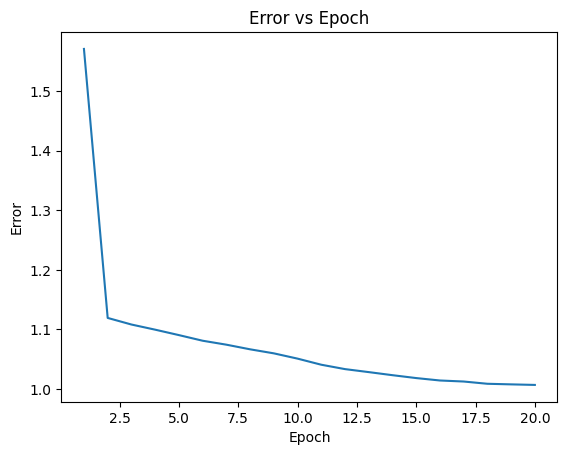

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ... (previous code for MultiHeadAttention, TransformerBlock, and Transformer remains the same)

def initialize_weights_with_mean_activations(model, dataloader, device):
    model.eval()
    weight_activations = defaultdict(list)

    def hook_fn(module, input, output):
        if isinstance(module, nn.Linear):
            weight_activations[module].append(input[0].detach())

    hooks = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            model(data, mask=None)

    for hook in hooks:
        hook.remove()

    for module, activations in weight_activations.items():
        mean_activation = torch.mean(torch.cat(activations, dim=0), dim=0)
        if mean_activation.shape[0] != module.weight.shape[1]:
            print(f"Skipping weight initialization for module with incompatible shapes: {mean_activation.shape} vs {module.weight.shape}")
            continue
        mean_activation = mean_activation.view(1, -1)
        new_weight = mean_activation.repeat(module.weight.shape[0], 1)
        module.weight.data = new_weight

    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, nn.Linear):
                weight_norm = torch.norm(module.weight.data, p=2, dim=1, keepdim=True)
                module.weight.data = module.weight.data / (weight_norm + 1e-5)  # Added small epsilon to avoid division by zero

    model.train()

# Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_samples = 1000
seq_len = 10
input_dim = 20
output_dim = 20
embed_size = 256
num_layers = 6
heads = 8
forward_expansion = 4
dropout = 0.1
learning_rate = 0.001
batch_size = 64
num_epochs = 20

# Data
X, Y = generate_synthetic_data(num_samples, seq_len, input_dim, output_dim)
train_data = torch.utils.data.TensorDataset(X, Y)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Model
model = Transformer(embed_size, num_layers, heads, device, forward_expansion, dropout, input_dim, seq_len).to(device)

# Initialize weights with mean activations
initialize_weights_with_mean_activations(model, train_loader, device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training
errors = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        # Forward
        predictions = model(data, mask=None)
        loss = criterion(predictions, targets)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    errors.append(epoch_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

# Plotting the error
plt.plot(range(1, num_epochs + 1), errors)
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error vs Epoch')
plt.show()